<a href="https://www.kaggle.com/code/sonawanelalitsunil/techcorner-mobile-engagement-data-ml-75-77?scriptVersionId=229312393" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/techcorner-mobile-purchase-and-engagement-data/TechCorner_Sales_update.csv


## Title: TechCorner Mobile Engagement Data



#### Description: Mobile purchase and user engagement dataset from TechCorner, capturing buying behavior and interaction trends.

## import dataset

In [2]:
df = pd.read_csv("/kaggle/input/techcorner-mobile-purchase-and-engagement-data/TechCorner_Sales_update.csv")

In [3]:
df.head()

,Cus.ID,Date,Cus. Location,Age,Gender,Mobile Name,Sell Price,Does he/she Come from Facebook Page?,Does he/she Followed Our Page?,Did he/she buy any mobile before?,Did he/she hear of our shop before?
0,1,27-05-2024,Rangamati Sadar,49,F,Galaxy A55 5G 8/128,17073.0,No,Yes,No,Yes
1,2,27-05-2024,Inside Rangamati,44,M,Redmi Note 12 Pro 8/128,15546.0,Yes,No,No,Yes
2,3,27-05-2024,Rangamati Sadar,45,M,R-70 Turbo 5G 6/128,26516.0,Yes,No,No,Yes
3,4,27-05-2024,Rangamati Sadar,46,M,R-70 Turbo 5G 6/128,21927.0,No,No,No,Yes
4,5,27-05-2024,Outside Rangamati,27,F,Vivo T3x 5G 8/128,16718.0,Yes,No,No,Yes


In [4]:
df.tail()

,Cus.ID,Date,Cus. Location,Age,Gender,Mobile Name,Sell Price,Does he/she Come from Facebook Page?,Does he/she Followed Our Page?,Did he/she buy any mobile before?,Did he/she hear of our shop before?
8866,8867,22-03-2025,Outside Rangamati,34,M,iQOO Neo 9 Pro 5G 12/256,21682.0,Yes,Yes,Yes,Yes
8867,8868,22-03-2025,Inside Rangamati,48,M,Moto G85 5G 8/128,26493.0,No,No,No,No
8868,8869,22-03-2025,Inside Rangamati,30,F,Galaxy M35 5G 8/128,16184.0,No,No,No,No
8869,8870,22-03-2025,Inside Rangamati,22,F,Galaxy A55 5G 8/128,16663.0,Yes,No,No,Yes
8870,8871,22-03-2025,Outside Rangamati,22,M,Note 14 Pro 5G 8/256,20781.0,Yes,Yes,Yes,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8871 entries, 0 to 8870
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Cus.ID                                8871 non-null   int64  
 1   Date                                  8871 non-null   object 
 2   Cus. Location                         8871 non-null   object 
 3   Age                                   8871 non-null   int64  
 4   Gender                                8871 non-null   object 
 5   Mobile Name                           8871 non-null   object 
 6   Sell Price                            8871 non-null   float64
 7   Does he/she Come from Facebook Page?  8871 non-null   object 
 8   Does he/she Followed Our Page?        8871 non-null   object 
 9   Did he/she buy any mobile before?     8871 non-null   object 
 10  Did he/she hear of our shop before?   8871 non-null   object 
dtypes: float64(1), in

In [6]:
df.describe()

,Cus.ID,Age,Sell Price
count,8871.000000,8871.000000,8871.00000
mean,4436.000000,34.047007,25068.38654
std,2560.981452,9.592612,18032.80271
min,1.000000,18.000000,12702.00000
25%,2218.500000,26.000000,17466.50000
50%,4436.000000,34.000000,21682.00000
75%,6653.500000,42.000000,25777.50000
max,8871.000000,50.000000,200465.00000


In [7]:
df.isnull().sum()

Cus.ID                                  0
Date                                    0
Cus. Location                           0
Age                                     0
Gender                                  0
Mobile Name                             0
Sell Price                              0
Does he/she Come from Facebook Page?    0
Does he/she Followed Our Page?          0
Did he/she buy any mobile before?       0
Did he/she hear of our shop before?     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.corr

<bound method DataFrame.corr of       Cus.ID        Date      Cus. Location  Age Gender  \
0          1  27-05-2024    Rangamati Sadar   49      F   
1          2  27-05-2024   Inside Rangamati   44      M   
2          3  27-05-2024    Rangamati Sadar   45      M   
3          4  27-05-2024    Rangamati Sadar   46      M   
4          5  27-05-2024  Outside Rangamati   27      F   
...      ...         ...                ...  ...    ...   
8866    8867  22-03-2025  Outside Rangamati   34      M   
8867    8868  22-03-2025   Inside Rangamati   48      M   
8868    8869  22-03-2025   Inside Rangamati   30      F   
8869    8870  22-03-2025   Inside Rangamati   22      F   
8870    8871  22-03-2025  Outside Rangamati   22      M   

                   Mobile Name  Sell Price  \
0          Galaxy A55 5G 8/128     17073.0   
1      Redmi Note 12 Pro 8/128     15546.0   
2          R-70 Turbo 5G 6/128     26516.0   
3          R-70 Turbo 5G 6/128     21927.0   
4            Vivo T3x 5G 8/12

In [10]:
df.shape

(8871, 11)

In [11]:
df.dtypes

Cus.ID                                    int64
Date                                     object
Cus. Location                            object
Age                                       int64
Gender                                   object
Mobile Name                              object
Sell Price                              float64
Does he/she Come from Facebook Page?     object
Does he/she Followed Our Page?           object
Did he/she buy any mobile before?        object
Did he/she hear of our shop before?      object
dtype: object

In [12]:
df.columns

Index(['Cus.ID', 'Date', 'Cus. Location', 'Age', 'Gender', 'Mobile Name',
       'Sell Price', 'Does he/she Come from Facebook Page?',
       'Does he/she Followed Our Page?', 'Did he/she buy any mobile before?',
       'Did he/she hear of our shop before?'],
      dtype='object')

## Data visualizations

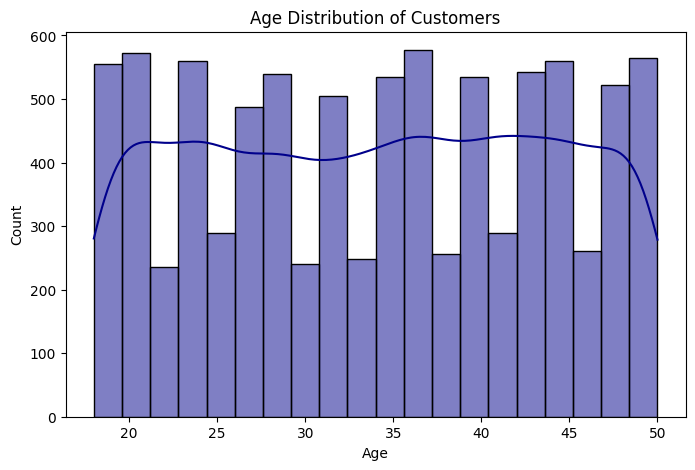

In [13]:
# Plot Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='darkblue')
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

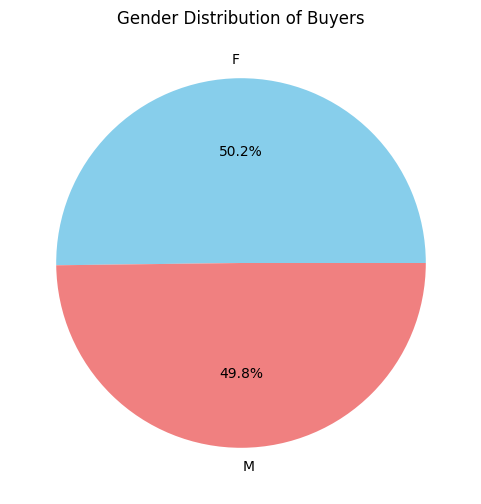

In [14]:
plt.figure(figsize=(6, 6))
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title("Gender Distribution of Buyers")
plt.ylabel("")
plt.show()

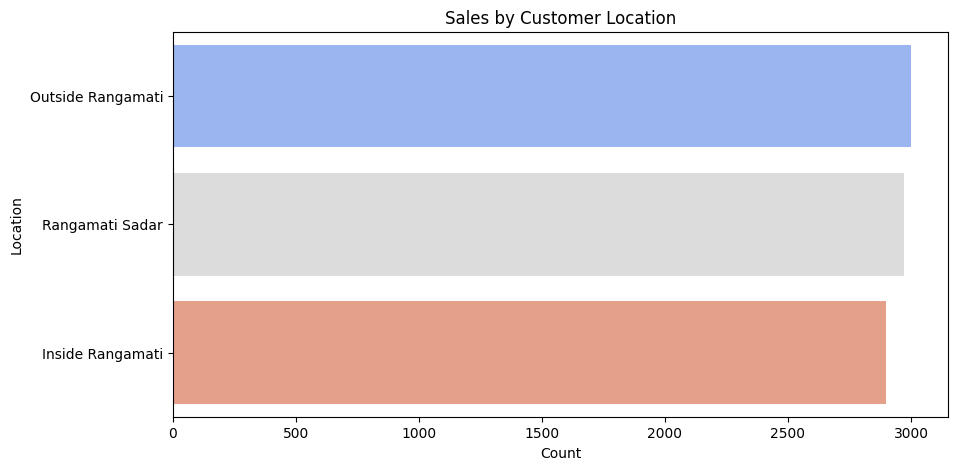

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(y=df['Cus. Location'], order=df['Cus. Location'].value_counts().index, palette='coolwarm')
plt.title("Sales by Customer Location")
plt.xlabel("Count")
plt.ylabel("Location")
plt.show()

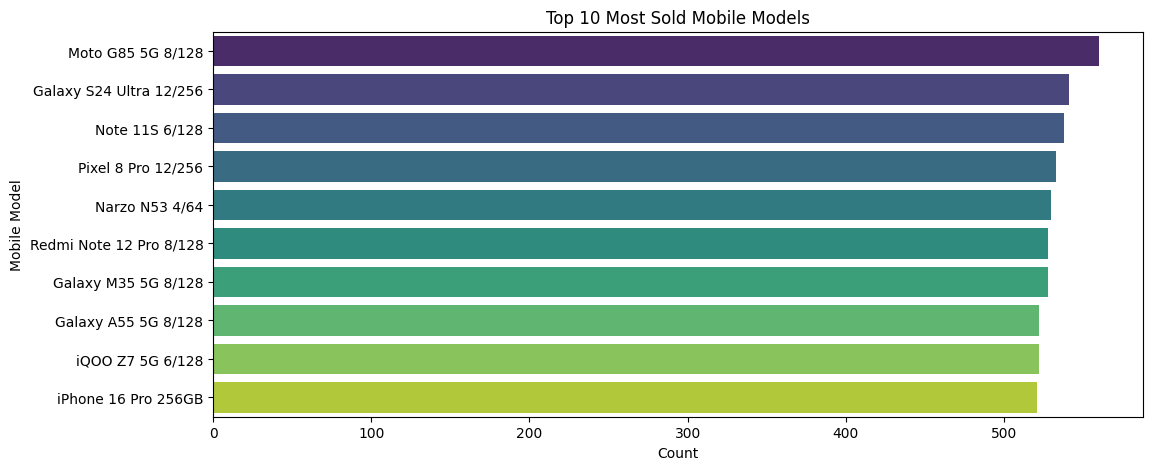

In [16]:
plt.figure(figsize=(12, 5))
sns.countplot(y=df['Mobile Name'], order=df['Mobile Name'].value_counts().index[:10], palette='viridis')
plt.title("Top 10 Most Sold Mobile Models")
plt.xlabel("Count")
plt.ylabel("Mobile Model")
plt.show()

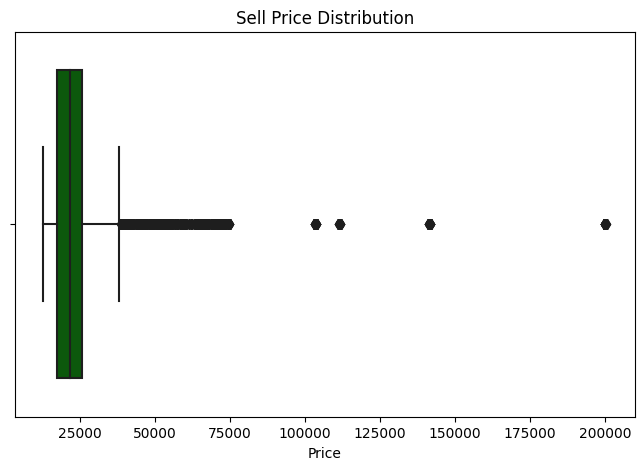

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Sell Price'], color='darkgreen')
plt.title("Sell Price Distribution")
plt.xlabel("Price")
plt.show()

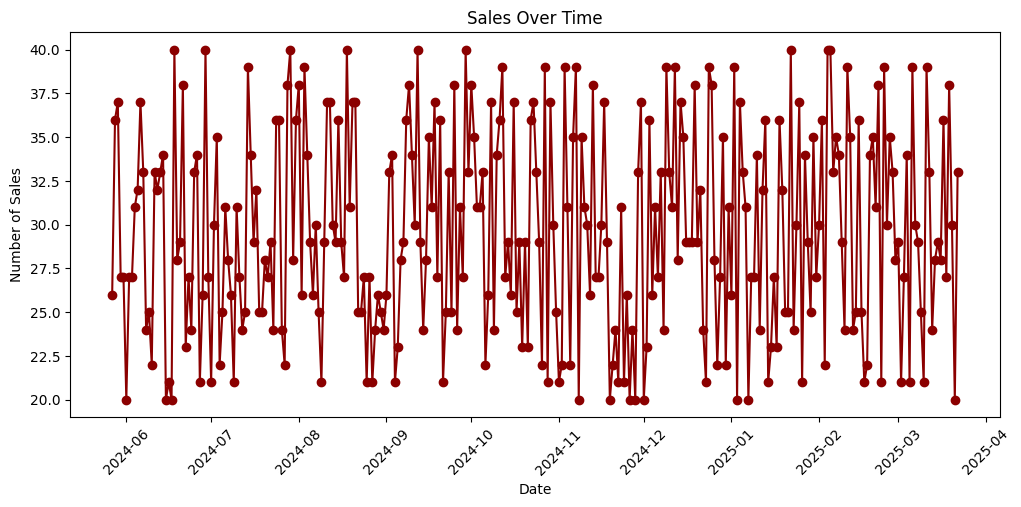

In [18]:
df['Date'] = pd.to_datetime(df['Date'])  # Convert to datetime
sales_over_time = df.groupby(df['Date'].dt.date).size()

plt.figure(figsize=(12, 5))
plt.plot(sales_over_time, marker='o', linestyle='-', color='darkred')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)
plt.show()


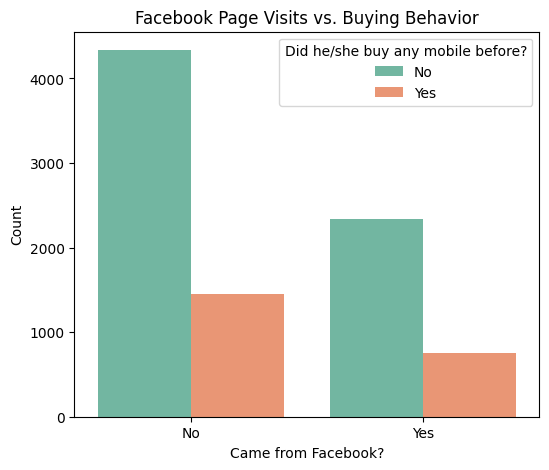

In [19]:
plt.figure(figsize=(6, 5))
sns.countplot(x=df['Does he/she Come from Facebook Page?'], hue=df['Did he/she buy any mobile before?'], palette='Set2')
plt.title("Facebook Page Visits vs. Buying Behavior")
plt.xlabel("Came from Facebook?")
plt.ylabel("Count")
plt.show()


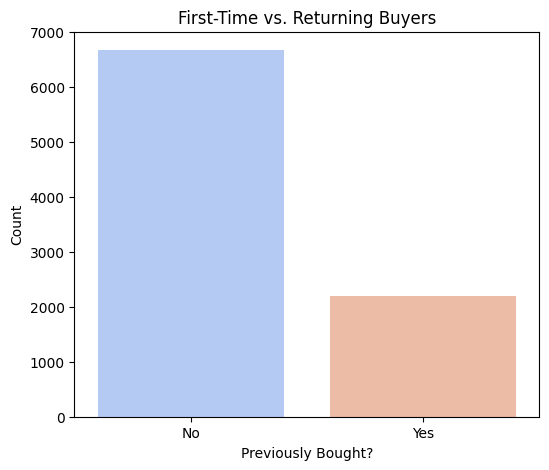

In [20]:
plt.figure(figsize=(6, 5))
sns.countplot(x=df['Did he/she buy any mobile before?'], palette='coolwarm')
plt.title("First-Time vs. Returning Buyers")
plt.xlabel("Previously Bought?")
plt.ylabel("Count")
plt.show()


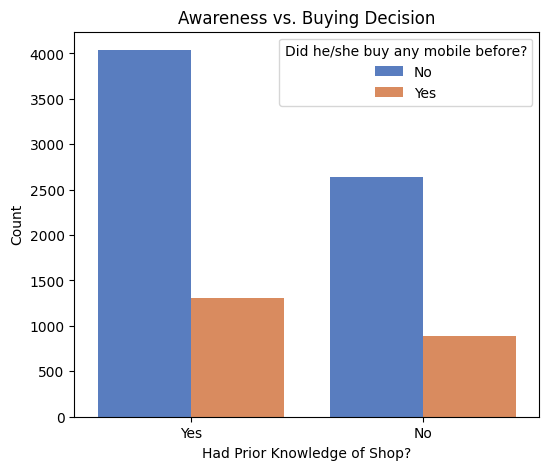

In [21]:
plt.figure(figsize=(6, 5))
sns.countplot(x=df['Did he/she hear of our shop before?'], hue=df['Did he/she buy any mobile before?'], palette='muted')
plt.title("Awareness vs. Buying Decision")
plt.xlabel("Had Prior Knowledge of Shop?")
plt.ylabel("Count")
plt.show()


## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
# Drop unnecessary columns (Customer ID, Date)
df = df.drop(columns=['Cus.ID', 'Date'])

In [24]:
# Label Encoding for categorical features
categorical_columns = ['Cus. Location', 'Gender', 'Mobile Name',
                       'Does he/she Come from Facebook Page?', 
                       'Does he/she Followed Our Page?', 
                       'Did he/she buy any mobile before?', 
                       'Did he/she hear of our shop before?']


In [25]:
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [26]:
# Define Features & Target
X = df.drop(columns=['Did he/she buy any mobile before?'])  # Features
y = df['Did he/she buy any mobile before?']  # Target (Buy or Not)

In [27]:
# Split into Training & Testing (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [29]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}


In [30]:
# Train & Evaluate Each Model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)  # Train Model
    y_pred = model.predict(X_test)  # Predictions
    acc = accuracy_score(y_test, y_pred)  # Accuracy
    results[name] = acc

# Show Accuracy of Models
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.757746
1        Decision Tree  0.624225
2        Random Forest  0.727887
3              XGBoost  0.716620


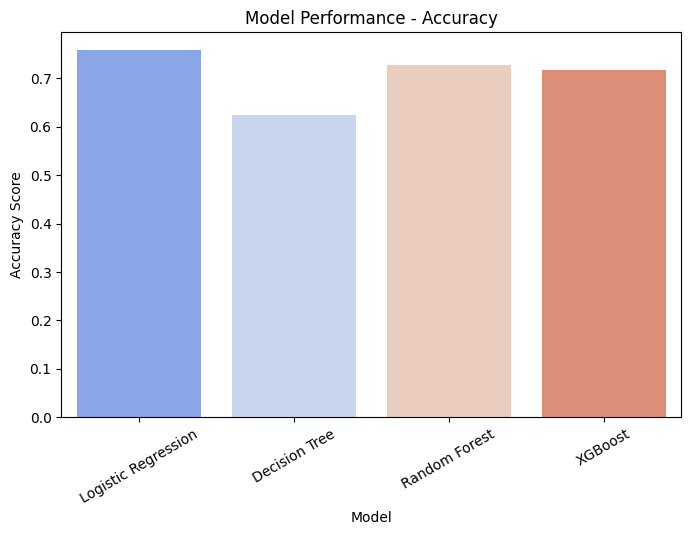

In [31]:
plt.figure(figsize=(8, 5))
sns.barplot(x=results_df["Model"], y=results_df["Accuracy"], palette="coolwarm")
plt.title("Model Performance - Accuracy")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=30)
plt.show()


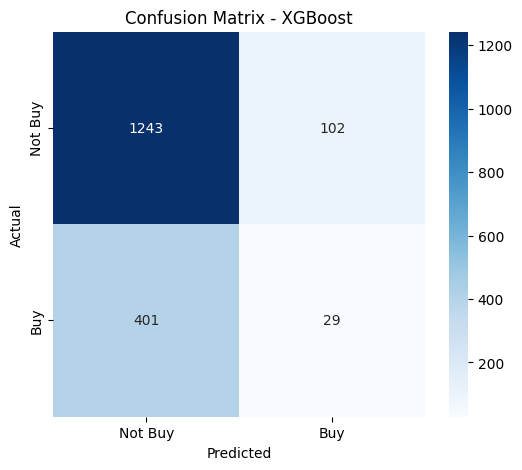

In [32]:
best_model = models["XGBoost"]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Buy", "Buy"], yticklabels=["Not Buy", "Buy"])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


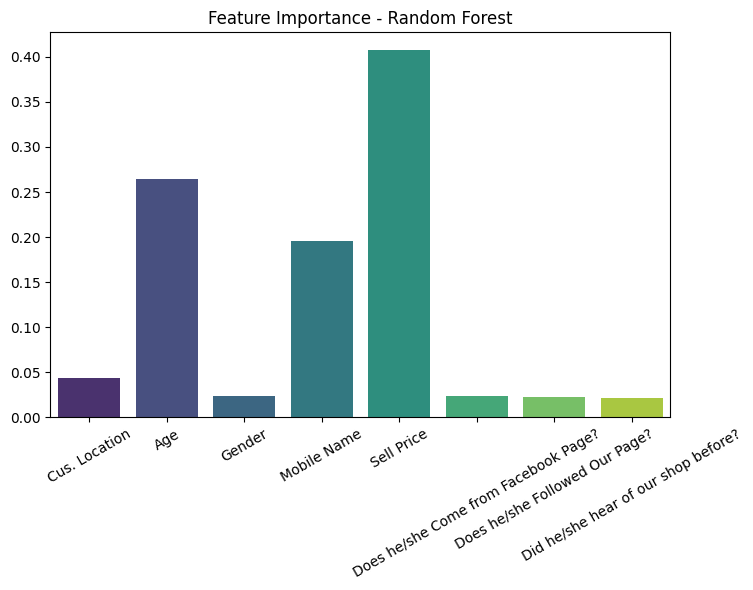

In [33]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

plt.figure(figsize=(8, 5))
sns.barplot(x=X.columns, y=importances, palette="viridis")
plt.title("Feature Importance - Random Forest")
plt.xticks(rotation=30)
plt.show()


## Thank you...pls upvote!!